# 🦜🔗 LangChain Crash Course (3–5 Hours)
### Using FREE Groq API | Complete Beginner to Intermediate

---

## Table of Contents
1. [Setup & Installation](#1-setup)
2. [LLMs & Chat Models with Groq](#2-llms)
3. [Prompt Templates](#3-prompts)
4. [LCEL — LangChain Expression Language (Chains)](#4-lcel)
5. [Output Parsers](#5-parsers)
6. [Memory & Conversation History](#6-memory)
7. [Document Loaders & Text Splitters](#7-docs)
8. [Embeddings & Vector Stores](#8-vectors)
9. [RAG — Retrieval Augmented Generation](#9-rag)
10. [Agents & Tools](#10-agents)

---
**Get your FREE Groq API key at:** https://console.groq.com


---
## 1. Setup & Installation
### What is LangChain?
LangChain is a framework for building applications powered by Large Language Models (LLMs).

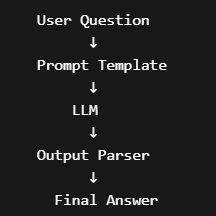

It provides:

- **Chains** — sequence LLM calls     
In LangChain, we connect things like this:-   
Prompt → LLM → Output    
This is called a chain.

- **Memory** — persist state across calls
Memory means remembering things.  
Like chat history.  

- **Agents** — let LLMs take actions with tools
They can take decisions.    
They can use tools.    
agent = brain + action

Example:

User asks:
What is 10 * 20?
- **RAG** — ground LLMs in your own data

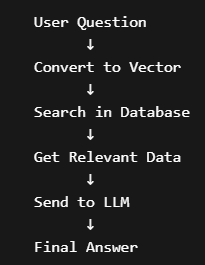

### Why Groq?
Groq provides **blazing fast inference** on LLaMA 3, Mixtral, and Gemma models — all **FREE** on the developer tier!

In [ ]:
# Install all required packages
!pip install langchain langchain-groq langchain-community langchain-huggingface
!pip install faiss-cpu sentence-transformers pypdf python-dotenv
!pip install duckduckgo-search streamlit

In [ ]:
from dotenv import load_dotenv
import os

# 👇 IMPORTANT: yeh line change karo
load_dotenv(dotenv_path="./.env", override=True)

#print("KEY:", os.getenv("GROQ_API_KEY"))

---
## 2. LLMs & Chat Models with Groq

### Key Groq Models (all free):
| Model | Context | Best For |
|-------|---------|----------|
| `llama3-8b-8192` | 8k | Fast, general tasks |
| `llama3-70b-8192` | 8k | Complex reasoning |
| `mixtral-8x7b-32768` | 32k | Long documents |
| `gemma2-9b-it` | 8k | Instruction following |

### Two Ways to Use LLMs in LangChain:
1. **`ChatGroq`** — Chat models (recommended, uses messages)
2. **`Groq`** — Text completion (older style)

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7,      # 0 = deterministic, 1 = creative
    max_tokens=1024,
)

print(f"Model: {llm.model_name}")

In [ ]:
# Basic invocation — simplest way to call an LLM
response = llm.invoke("What is LangChain in one sentence?")

print(type(response))       # AIMessage object
print(response.content)     # The actual text
print(response.usage_metadata)  # Token usage


In [ ]:
# Using Messages directly — how Chat Models work internally

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

messages = [
    SystemMessage(content="You are a helpful Python tutor. Be concise."),
    HumanMessage(content="What is a list comprehension?"),
]


response = llm.invoke(messages)
print(response.content)

In [ ]:
# Streaming — get tokens as they're generated

print("Streaming response:")
print("-" * 40)
for chunk in llm.stream("Tell me 3 facts about Python programming."):
    print(chunk.content, end="", flush=True)
print()  # newline at end

In [ ]:
# Batch — run multiple prompts at once (efficient!)
prompts = [
    "What is Python?",
    "What is JavaScript?",
    "What is Rust?",
]

responses = llm.batch(prompts)
for prompt, resp in zip(prompts, responses):
    print(f"Q: {prompt}")
    print(f"A: {resp.content[:100]}...")
    print()

---
## 3. Prompt Templates

Prompt Templates allow you to create **reusable, dynamic prompts** with variables.

### Types:
- `PromptTemplate` — for simple string prompts
- `ChatPromptTemplate` — for chat-style prompts (most common)
- `FewShotPromptTemplate` — includes examples to guide the LLM

In [ ]:
from langchain_core.prompts import PromptTemplate

# Basic PromptTemplate — use {variable} placeholders
template = PromptTemplate(
    input_variables=["topic", "level"],
    template="Explain {topic} to a {level} in 3 bullet points."
)


# Format the prompt
formatted = template.format(topic="neural networks", level="10-year-old")
print(formatted)
print()

# Invoke the LLM with the formatted prompt
response = llm.invoke(formatted)
print(response.content)

In [ ]:

# chatprompttemp

from langchain_core.prompts import ChatPromptTemplate

# ChatPromptTemplate — the modern, recommended approach
chat_template = ChatPromptTemplate.from_messages([
    ("system", "You are an expert {domain} teacher. Always be encouraging."),
    ("human", "Explain {concept} in simple terms."),
])


# Format returns a list of messages
messages = chat_template.format_messages(
    domain="machine learning",
    concept="gradient descent"
)

for msg in messages:
    print(f"{type(msg).__name__}: {msg.content}")
    print()

In [ ]:
# Invoke LLM with a ChatPromptTemplate
response = llm.invoke(messages)
print(response.content)


In [ ]:
# fewshot prompt

from langchain_core.prompts import FewShotPromptTemplate

# FewShotPromptTemplate — teach the model with examples
examples = [
    {"word": "happy", "antonym": "sad"},
    {"word": "tall",  "antonym": "short"},
    {"word": "fast",  "antonym": "slow"},
]

example_template = PromptTemplate(
    input_variables=["word", "antonym"],
    template="Word: {word}\nAntonym: {antonym}"
)

few_shot = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_template,
    prefix="Give the antonym of each word:",
    suffix="Word: {input}\nAntonym:",
    input_variables=["input"]
)


formatted = few_shot.format(input="bright")

print(formatted)
print()
print("LLM Response:", llm.invoke(formatted).content)



In [ ]:
# MessagesPlaceholder — dynamic injection of conversation history
from langchain_core.prompts import MessagesPlaceholder

chat_with_history = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    MessagesPlaceholder(variable_name="history"),  # inject history here
    ("human", "{input}"),
])


# Simulate a conversation history
history = [
    HumanMessage(content="My name is Nidhi."),
    AIMessage(content="Nice to meet you, Nidhi!"),
]
messages = chat_with_history.format_messages(history=history, input="What is my name?")

response = llm.invoke(messages)
print(response.content)  # Should remember 'Nidhi'


---
## 4. LCEL — LangChain Expression Language (Chains)

LCEL is the **modern way** to compose LangChain components using the pipe `|` operator.

```
chain = prompt | llm | output_parser
```

Benefits of LCEL:
- Built-in streaming, batching, async
- Easy to compose and modify
- Type-safe with clear data flow
- Replaces old `LLMChain`, `SequentialChain`

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# The simplest LCEL chain: prompt | llm | parser
prompt = ChatPromptTemplate.from_messages([
    ("human", "Tell me a {adjective} joke about {topic}.")
])

parser = StrOutputParser()  # converts AIMessage -> plain string

chain = prompt | llm | parser


# Invoke with a dict of inputs
result = chain.invoke({"adjective": "funny", "topic": "Python"})
print(result)
print(type(result))  # str, not AIMessage


In [ ]:
print("Streaming joke:")

for chunk in chain.stream({
    "adjective" : "terrible",
    "topic": "AI"}):
    print(chunk, end = "", flush = True)

print()    

In [ ]:

# Batch with LCEL — run many inputs at once
inputs = [
    {"adjective": "dad", "topic": "cats"},
    {"adjective": "nerdy", "topic": "databases"},
    {"adjective": "quick", "topic": "cloud computing"},
]

results = chain.batch(inputs)

for i, r in enumerate(results, 1):
    print(f"Joke {i}: {r[:80]}...")
    print()



In [ ]:
# Sequential Chains — chain outputs become next chain's inputs
from langchain_core.runnables import RunnablePassthrough

# Chain 1: Generate a topic
topic_prompt = ChatPromptTemplate.from_messages([
    ("human", "Give me one interesting topic in {field}. Reply with just the topic name.")
])

topic_chain = topic_prompt | llm | StrOutputParser()

# Chain 2: Write about that topic
essay_prompt = ChatPromptTemplate.from_messages([
    ("human", "Write 3 sentences about: {topic}")
])


essay_chain = essay_prompt | llm | StrOutputParser()


# Combine: output of topic_chain feeds into essay_chain
full_chain = topic_chain | (lambda topic: {"topic": topic}) | essay_chain

result = full_chain.invoke({"field": "quantum computing"})
print(result)



In [ ]:

# RunnableParallel — run multiple chains at the same time
from langchain_core.runnables import RunnableParallel

pros_prompt = ChatPromptTemplate.from_messages([
    ("human", "List 3 pros of {technology} in bullet points.")
])
cons_prompt = ChatPromptTemplate.from_messages([
    ("human", "List 3 cons of {technology} in bullet points.")
])

pros_chain = pros_prompt | llm | StrOutputParser()
cons_chain = cons_prompt | llm | StrOutputParser()

parallel_chain = RunnableParallel(
    pros=pros_chain,
    cons=cons_chain,
)

result = parallel_chain.invoke({"technology": "Python"})

print("PROS:")
print(result["pros"])
print("\nCONS:")
print(result["cons"])

In [ ]:
# RunnablePassthrough — pass input through unchanged
from langchain_core.runnables import RunnablePassthrough

# Useful when you want to preserve the original input alongside chain output
chain_with_input = RunnableParallel(
    original=RunnablePassthrough(),
    response=ChatPromptTemplate.from_messages([
        ("human", "Translate '{text}' to French.")
    ]) | llm | StrOutputParser()
)

result = chain_with_input.invoke({"text": "Hello, how are you?"})
print("Original:", result["original"])
print("French:", result["response"])

---
## 5. Output Parsers

Output parsers transform the LLM's raw text output into structured Python objects.

| Parser | Output Type | Use Case |
|--------|-------------|----------|
| `StrOutputParser` | `str` | Plain text |
| `JsonOutputParser` | `dict` | JSON data |
| `PydanticOutputParser` | `BaseModel` | Validated objects |
| `CommaSeparatedListOutputParser` | `list` | Simple lists |

In [ ]:
from langchain_core.output_parsers import JsonOutputParser

# JSON Output Parser — get structured data back
json_prompt = ChatPromptTemplate.from_messages([
    ("system", "Always respond with valid JSON."),
    ("human", "Give me info about {person} as JSON with keys: name, field, achievement.")
])

# LCEL CHAIN

json_chain = json_prompt | llm | JsonOutputParser()

result = json_chain.invoke({"person": "Alan Turing"})


print(type(result))  # dict!
print(result)
print(result["name"])  # Access like a normal dict


In [ ]:
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import List

# Define what you want the output to look like
class MovieReview(BaseModel):
    title: str = Field(description="Movie title")
    rating: float = Field(description="Rating from 0 to 10")
    pros: List[str] = Field(description="List of pros")
    cons: List[str] = Field(description="List of cons")
    summary: str = Field(description="One sentence summary")

parser = PydanticOutputParser(pydantic_object=MovieReview)

# Get format instructions to include in the prompt
print(parser.get_format_instructions()[:300])

In [ ]:
movie_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a movie critic. {format_instructions}"),
    ("human", "Review the movie: {movie}")
])

movie_chain = movie_prompt | llm | parser


review = movie_chain.invoke({
    "movie": "Inception",
    "format_instructions": parser.get_format_instructions()
})

print(type(review))  
print(f"Title: {review.title}")
print(f"Rating: {review.rating}/10")
print(f"Pros: {review.pros}")
print(f"Cons: {review.cons}")
print(f"Summary: {review.summary}")



In [ ]:
from langchain_core.output_parsers import CommaSeparatedListOutputParser

list_parser = CommaSeparatedListOutputParser()
# convert commas seprate text into python

list_prompt = ChatPromptTemplate.from_messages([
    ("human", "List 5 {category}. {format_instructions}")
])

list_chain = list_prompt | llm | list_parser

result = list_chain.invoke({
    "category": "popular Python libraries",
    "format_instructions": list_parser.get_format_instructions()
})

print(type(result))  # list!
for i, item in enumerate(result, 1):
    print(f"{i}. {item.strip()}")

---
## 6. Memory & Conversation History

Memory allows your chatbot to **remember previous messages**.

### Modern LangChain Memory Approaches:
1. **Manual history** — store messages in a Python list (simplest)
2. **`ChatMessageHistory`** — LangChain's message store
3. **`RunnableWithMessageHistory`** — automatic history management
4. **Summary Memory** — summarize old messages to save tokens

In [ ]:
# Approach 1: Manual history (simplest, most transparent)
from langchain_core.messages import HumanMessage, AIMessage


chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Remember the conversation."),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}")
])

chain = chat_prompt | llm | StrOutputParser()

# Store conversation
history = []

def chat(user_input):
    response = chain.invoke({"input": user_input, "history": history})
    history.append(HumanMessage(content=user_input))
    history.append(AIMessage(content=response))
    return response
# Simulate a conversation
print("You:", "Hi, my name is Nidhi and I love Python.")
print("Bot:", chat("Hi, my name is Nidhi and I love Python."))
print()   
print("You:", "What programming language do I love?")
print("Bot:", chat("What programming language do I love?"))
print() 
print("You:", "What is my name?")
print("Bot:", chat("What is my name?"))

In [ ]:
# Approach 2: RunnableWithMessageHistory — production-ready memory
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

# Store for different sessions (like different users)
store = {}  # {session_id: ChatMessageHistory}

def get_session_history(session_id: str) -> ChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}")
])

base_chain = prompt | llm | StrOutputParser()

# Wrap with message history management
# add atomatic memory
chain_with_history = RunnableWithMessageHistory(
    base_chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="history",
)

# Use session_id to track different conversations
config_user1 = {"configurable": {"session_id": "user_alice"}}
config_user2 = {"configurable": {"session_id": "user_bob"}}

# Alice's conversation
r1 = chain_with_history.invoke({"input": "I'm Alice, I like cats."}, config=config_user1)
print("Alice 1:", r1)



# Bob's conversation
r2 = chain_with_history.invoke({"input": "I'm Bob, I like dogs."}, config=config_user2)
print("Bob 1:", r2)


# Alice asks again — should remember she likes cats
r3 = chain_with_history.invoke({"input": "What pet do I like?"}, config=config_user1)
print("Alice 2:", r3)


# Bob asks — should remember he likes dogs
r4 = chain_with_history.invoke({"input": "What pet do I like?"}, config=config_user2)
print("Bob 2:", r4)



In [ ]:
# Approach 3: Window Memory — only keep last N messages
from langchain_core.chat_history import InMemoryChatMessageHistory

WINDOW_SIZE = 4  
# keep last 4 messages (2 exchanges)
# 2 = user msg
# 2 ai msg

history_windowed = []
# store all msg

def chat_windowed(user_input):
    # Only pass last WINDOW_SIZE messages
    recent = history_windowed[-WINDOW_SIZE:]
    
    response = chain.invoke({"input": user_input, "history": recent})

    
    history_windowed.append(HumanMessage(content=user_input))
    history_windowed.append(AIMessage(content=response))
    return response

print("Window Memory Demo:")
chat_windowed("My favorite color is blue.")
chat_windowed("I live in Mumbai.")
chat_windowed("I work as a data scientist.")

# After window slides, might forget favorite color
result = chat_windowed("What is my favorite color?")
print(result)  # May or may not remember — depends on window

print(f"Total messages stored: {len(history_windowed)}")
print(f"Messages used in last call: {WINDOW_SIZE}")

---
## 7. Document Loaders & Text Splitters

Before we can do RAG, we need to:
1. **Load** documents from various sources
2. **Split** them into smaller chunks

Step 1: Load document
→ PDF, text file, website

Step 2: Split document
→ break into small chunks

Step 3: Store chunks
→ later used in search

### Why split? 
LLMs have limited context windows. We split docs into small chunks, store them, and retrieve only the relevant chunks at query time.

Load → Split → Store → Retrieve

#### Document Loader — 
We convert file into Document object  , LangChain works with Document format  , Loader converts raw file → structured document
#### Core Understanding
File → Loader → Document → Ready for splitting
#### One-Line Summary
TextLoader loads file into LangChain Document format

In [ ]:
from langchain_community.document_loaders import TextLoader

# Create a sample text file to load
sample_text = """LangChain is a framework for developing applications powered by large language models.

It enables applications that:
- Are context-aware: connect a language model to sources of context
- Can reason: rely on a language model to reason about what actions to take

The main components of LangChain are:
1. Models: LLMs and Chat Models
2. Prompts: Prompt Templates and Example Selectors
3. Chains: Sequences of calls to LLMs or other utilities
4. Memory: Persist application state between runs
5. Agents: Let LLMs take actions using tools
6. Retrievers: Interface for fetching relevant documents

LangChain was created by Harrison Chase and released in October 2022.
It quickly became one of the most popular open-source projects.
"""

# Write sample file
with open("sample_doc.txt", "w") as f:
    f.write(sample_text)

# Load the document
loader = TextLoader("sample_doc.txt", encoding="utf-8")
docs = loader.load()

print(f"Loaded {len(docs)} document(s)")
print(f"Document type: {type(docs[0])}")
print(f"Content preview: {docs[0].page_content[:100]}...")
print(f"Metadata: {docs[0].metadata}")

#### 📄 PDF Loader Notes
- PDF is broken into pages
- Each page becomes one document
#### Best Analogy
- Like a book  
- Each page is treated separately
#### Important Concept
- 1 PDF → many Documents  
- Each page = 1 Document  
#### Why This Is Important
- Later we split each page into smaller chunks  
- Then we store and search efficiently  
#### One-Line Summary  
- PDF → Pages → Documents



In [ ]:
from langchain_community.document_loaders import PyPDFLoader

# PDF Loader — load and split PDF pages automatically
# (Uncomment and use your own PDF file)
# loader = PyPDFLoader("your_document.pdf")
# pages = loader.load()  # Each page is a Document
# print(f"Loaded {len(pages)} pages")
# print(pages[0].page_content[:200])

print("PyPDFLoader: Use PyPDFLoader('path/to/file.pdf') to load PDF files")
print("Each page becomes a separate Document object")

#### 🌐 Web Loader Notes (LangChain)

#### 📌 Simple Explanation
We load data directly from a website.  
Then convert it into document format.


#### 🧠 Core Idea
Website → HTML → Clean Text → Document  


#### ✂️ Why Splitting is Needed
We break big document into small parts.  


#### 🔥 Best Analogy
Like copy-paste from a website,  
but done automatically by code.


#### ⚙️ Why `bs4` is Used
Website has a lot of noise (ads, menus, buttons).  
We extract only useful content.


#### ⚠️ Common Issue
If internet is not working → it will fail.  

That’s why we use `try-except`.


#### 🎯 One-Line Summary
Load website → clean content → convert to document  


#### 🎤 Transition
Now we will split this document into small chunks.

In [ ]:
import os
import bs4
os.environ["USER_AGENT"] = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
# set a user agent so website dont treat your script like sady bot

from langchain_community.document_loaders import WebBaseLoader

# Wikipedia — reliable, clean HTML, always works
loader = WebBaseLoader(
    web_paths=["https://en.wikipedia.org/wiki/Large_language_model"],
    bs_kwargs={
        "parse_only": bs4.SoupStrainer(id="mw-content-text")
        # only extract the main content section of the wikipedia page
        # this avoid navigation bars, side panel footer etc
    }
)

docs = loader.load()

print(f"Loaded {len(docs)} doc(s)")
print(docs[0].page_content[:500])


#### 📄 Text Splitting (LangChain Notes)

#### 📌 Basic Idea
We break big document into small parts.  
These parts are called **chunks**.



#### 🧠 Core Concept
Big document → small chunks → better understanding


#### ⚠️ Chunk Overlap (Very Important)
We repeat some part between chunks.  

So AI does not lose context.


#### 📊 Visual Understanding
```
Chunk 1: [AAAA BBBB CCCC]  
Chunk 2:       [CCCC DDDD EEEE]  
Chunk 3:             [EEEE FFFF GGGG]
```

#### ⚙️ Why Recursive Splitter is Best
It tries smart splitting:

- First paragraph  
- Then sentence  
- Then word  


#### 🎯 One-Line Summary
Split documents into small chunks for better AI processing



```
🔹 RecursiveCharacterTextSplitter
Uses multiple rules
Tries:
paragraph
line
sentence
word
Keeps text more natural
Adds overlap → better understanding
Basically:

“Let me try to split this nicely like a human would.
```

In [ ]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter
)

# RecursiveCharacterTextSplitter — BEST for most use cases
# Tries to split on paragraphs -> sentences -> words -> characters
splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,       # max characters per chunk
    chunk_overlap=30,     # overlap between chunks (for context)
    separators=["\n\n", "\n", ". ", " ", ""]  # try these in order

    # Order matters:
    # 1. Try splitting by paragraphs
    # 2. Then by line breaks
    # 3. Then by sentences
    # 4. Then by words
    # 5. Finally, brute-force split characters if nothing else works
)

chunks = splitter.split_documents(docs)
print(f"Original docs: {len(docs)}")
print(f"After splitting: {len(chunks)} chunks")
print()
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} ({len(chunk.page_content)} chars) ---")
    # show chunk num and its len
    print(chunk.page_content)
    print()

```
CharacterTextSplitter
Uses only one rule (\n)
If newline is missing → bad splits
Can break sentences randomly
No overlap → context lost

Basically:

“Cut here. I don’t care what the sentence says.”
```

In [ ]:
import logging
logging.getLogger("langchain_text_splitters").setLevel(logging.ERROR)

# CharacterTextSplitter — splits on a specific character
char_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=100,
    chunk_overlap=0
)

char_chunks = char_splitter.split_documents(docs)
print(f"CharacterTextSplitter produced {len(char_chunks)} chunks")

# Inspect overlap with RecursiveCharacterTextSplitter
print("\nChunk 0:", chunks[0].page_content[-50:])
print("Chunk 1 start:", chunks[1].page_content[:50])


---
## 8. Embeddings & Vector Stores

### How it works:
1. **Embed** text → convert to a list of numbers (vector)
2. **Store** vectors in a **vector database**
3. **Query** — embed the user's question, find most similar stored vectors
4. Return the **top-k most similar chunks**

### We'll use (all free, no API needed):
- **HuggingFace Embeddings** — runs locally on your machine
- **FAISS** — Facebook's fast vector similarity search


### 🎤 Simple Idea
- Convert text into **numbers (vectors)**
- Similar meaning → similar vectors



### 🔥 Process
1. Text → Vector  
2. Store in vector database  
3. Question → Vector  
4. Find similar vectors  
5. Return top results  


### 🧠 Key Concept
- AI understands **numbers, not raw text**


### 🧩 Tools Used
- HuggingFace → create embeddings  
- FAISS → store & search vectors  


### 🎯 One-Line Summary
Text → Vector → Search → Retrieve

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize embeddings — downloads model on first run (~90MB)
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True} # help in better similarity comparison
)

print("Embeddings model loaded!")

In [ ]:
# Embed a single piece of text
text = "LangChain is a framework for LLM applications."
vector = embeddings.embed_query(text) # convert text into num (vector)

print(f"Text: {text}")

print(f"Vector dimensions: {len(vector)}")
print(f"First 5 values: {vector[:5]}")
print("\nNote: Similar texts will have similar vectors!")

In [ ]:

# Demonstrate similarity
import numpy as np

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    #     dot pro / len of v1 * len  of v2
    # result -1, 1

v1 = embeddings.embed_query("I love programming in Python")
v2 = embeddings.embed_query("Python is my favorite coding language")
v3 = embeddings.embed_query("The weather today is sunny and warm")

sim_12 = cosine_similarity(v1, v2)
sim_13 = cosine_similarity(v1, v3)

print(f"Similarity (Python vs Python): {sim_12:.3f}")  # High!
print(f"Similarity (Python vs Weather): {sim_13:.3f}") # Low!

## chunk -> vector-> stored in vector db (Faiss)

num of vector = num of chunk

faiss store vectore for fast similarity search

In [ ]:
from langchain_community.vectorstores import FAISS

# Create a FAISS vector store from our document chunks
vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print(f"Vector store created with {vectorstore.index.ntotal} vectors")
# total num of vector stored
# usually =number of chunk

### Query -> vector -> Match(inside vector db) with similarity search-> Top result
#### similarity_search-> meaning searching

In [ ]:
# Similarity search — find most relevant chunks for a query
query = "what is LLM?"
results = vectorstore.similarity_search(query, k=2)

# convert query -> vector
# compare with store vector
# return top 2 most similar result

print(f"Query: '{query}'")
print(f"Found {len(results)} relevant chunks:")
print()
for i, doc in enumerate(results, 1):
    print(f"Result {i}: {doc.page_content}")
    print()

In [ ]:
# Similarity search with scores
results_with_scores = vectorstore.similarity_search_with_score(query, k=3)

# search top 3 similar chunks
# also return score for each result

for doc, score in results_with_scores:
    # doc = text chunk
    # score = similar score

    print(f"Score: {score:.4f} (lower = more similar in L2 distance)")
    # lower score = more similar
    # high score = less similar
    print(f"Content: {doc.page_content[:100]}") 
    # 1st 100 char of content
    print()

In [ ]:
# Save and load vector store
vectorstore.save_local("faiss_index")
print("Vector store saved!")

# Load it back
loaded_vs = FAISS.load_local(
    "faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)
print("Vector store loaded!")
print(f"Vectors: {loaded_vs.index.ntotal}")

In [ ]:
# Turn vector store into a Retriever — the standard interface
retriever = vectorstore.as_retriever(
    search_type="similarity",  # or "mmr" for diverse results
    search_kwargs={"k": 3}     # top 3 results
)

# Retrieve documents for a query
relevant_docs = retriever.invoke("type of llm?")
# convert Q -> vector
# search similar chunk
# Return relevent doc

print(f"Retrieved {len(relevant_docs)} documents")
for doc in relevant_docs:
    print(f"- {doc.page_content[:100]}...")
    # show 1st 100 char of each chunk